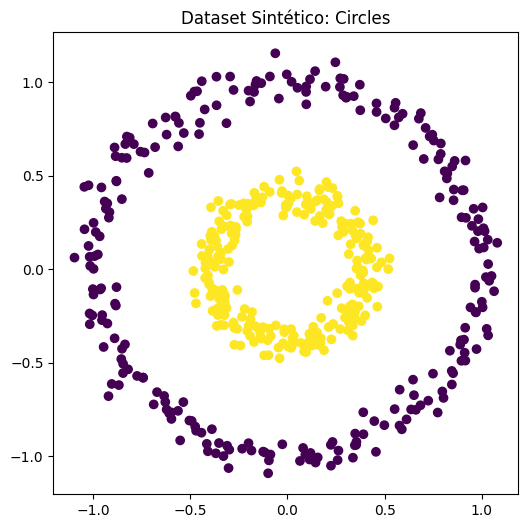

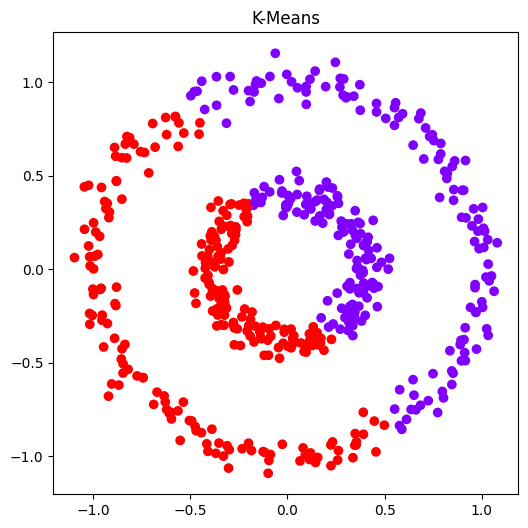

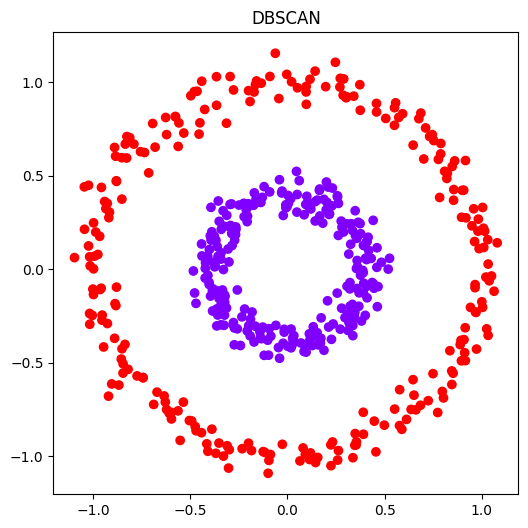

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


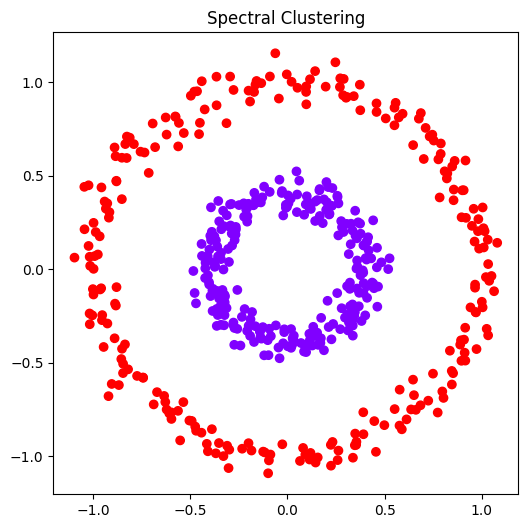

                Modelo       ARI  V-Measure  Silhouette  Davies-Bouldin
0              K-Means -0.001862   0.000104    0.329694        1.220680
1               DBSCAN  1.000000   1.000000    0.157443      205.775531
2  Spectral Clustering  1.000000   1.000000    0.157443      205.775531


In [ ]:
# ==========================================
# ACTIVIDAD 04 - CLUSTERING EN DATASET CIRCLE
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from sklearn.metrics import (
    adjusted_rand_score,
    v_measure_score,
    silhouette_score,
    davies_bouldin_score
)

# ---------------------------
# Generación del dataset
# ---------------------------

X, y_true = make_circles(
    n_samples=500,
    factor=0.4,
    noise=0.05,
    random_state=42
)

# Visualización
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=y_true, cmap='viridis')
plt.title("Dataset Sintético: Circles")
plt.show()

# ---------------------------
# Modelos de clustering
# ---------------------------

modelos = {
    "K-Means": KMeans(n_clusters=2, random_state=42, n_init=10),
    "DBSCAN": DBSCAN(eps=0.15, min_samples=5),
    "Spectral Clustering": SpectralClustering(
        n_clusters=2,
        affinity='nearest_neighbors',
        random_state=42
    )
}

resultados = []

# ---------------------------
# Entrenamiento y evaluación
# ---------------------------

for nombre, modelo in modelos.items():

    etiquetas = modelo.fit_predict(X)

    # Métricas externas
    ari = adjusted_rand_score(y_true, etiquetas)
    vmeasure = v_measure_score(y_true, etiquetas)

    # Métricas internas
    n_clusters = len(set(etiquetas)) - (1 if -1 in etiquetas else 0)

    if n_clusters > 1:
        sil = silhouette_score(X, etiquetas)
        db = davies_bouldin_score(X, etiquetas)
    else:
        sil = np.nan
        db = np.nan

    resultados.append([
        nombre,
        ari,
        vmeasure,
        sil,
        db
    ])

    # Gráfico
    plt.figure(figsize=(6,6))
    plt.scatter(X[:,0], X[:,1], c=etiquetas, cmap='rainbow')
    plt.title(nombre)
    plt.show()

# ---------------------------
# Tabla de resultados
# ---------------------------

df = pd.DataFrame(
    resultados,
    columns=[
        "Modelo",
        "ARI",
        "V-Measure",
        "Silhouette",
        "Davies-Bouldin"
    ]
)

print(df)

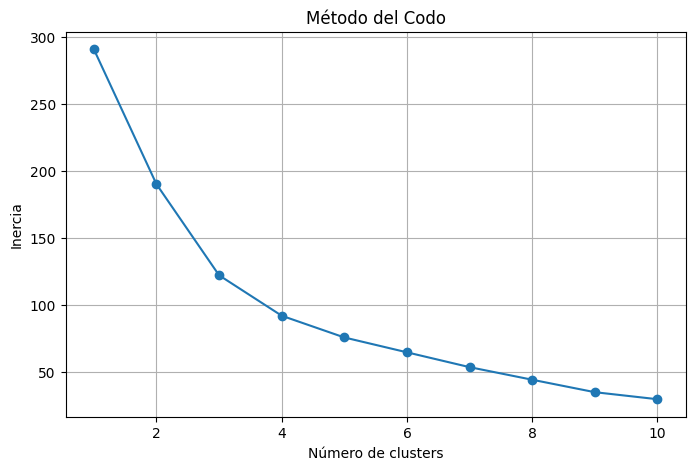

In [ ]:
from sklearn.cluster import KMeans

inercia = []

K = range(1,11)

for k in K:
    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo.fit(X)
    inercia.append(modelo.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inercia, marker='o')
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del Codo")
plt.grid(True)
plt.show()

#3. Explicación de las métricas
Métricas de validación externa
Adjusted Rand Index (ARI)

Compara las etiquetas reales con las etiquetas encontradas por el algoritmo.

Valores:

1 = agrupamiento perfecto

0 = agrupamiento aleatorio

< 0 = peor que aleatorio

V-Measure

Mide simultáneamente:

Homogeneidad
Completitud

Valores:

1 = agrupamiento perfecto

0 = agrupamiento incorrecto

Métricas de validación interna

Silhouette Score

Mide qué tan bien separado está cada cluster.

Valores:

Cerca de 1 → muy bien separado

Cerca de 0 → clusters superpuestos

Negativo → mala agrupación

Davies-Bouldin Index

Mide la similitud entre clusters.

Valores:

Más cercano a 0 → mejor

Valores altos → clusters poco diferenciados

Elbow Method

Analiza la disminución de la inercia conforme aumenta el número de clusters.

El punto donde la curva comienza a estabilizarse indica el número adecuado de grupos.